# 04 — Risk Analysis: Drawdown and Rolling Volatility

## Objective

The objective of this notebook is to analyze the risk profile of the momentum strategy
and compare it with the FEZ benchmark.

We focus on:
- drawdowns to measure downside risk
- maximum drawdown to quantify worst-case losses
- rolling volatility to assess how risk evolves over time

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 1. Load Backtest Data

We reuse the backtest summary table containing:
- monthly returns
- equity curves

In [2]:
backtest_summary = pd.read_csv("../data/backtest_summary.csv", index_col=0, parse_dates=True)

strategy_equity = backtest_summary["Strategy Equity"]
benchmark_equity = backtest_summary["FEZ Equity"]

strategy_returns = backtest_summary["Strategy Return"]
benchmark_returns = backtest_summary["FEZ Return"]

## 2. Drawdown

Drawdown measures the decline from a previous peak in the portfolio value.

**Drawdown = (Portfolio Value - Running Maximum) / Running Maximum**

It represents the percentage loss from the last peak.

Why it matters:
- captures downside risk
- reflects investor experience (losses matter more than gains)


## 3. Drawdown Plot

This plot shows the evolution of drawdowns over time for both the strategy and the benchmark.

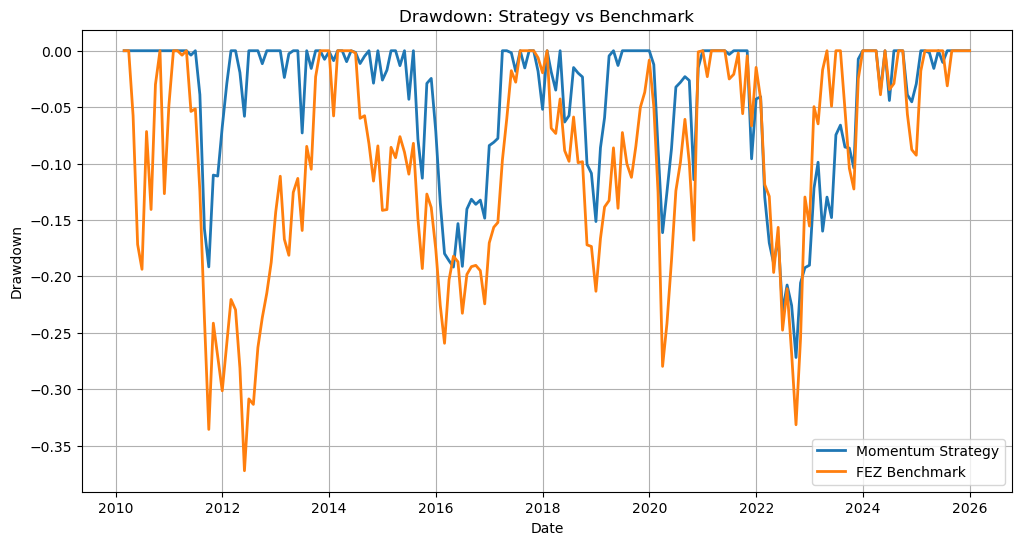

In [3]:
# Running maximum
strategy_peak = strategy_equity.cummax()
benchmark_peak = benchmark_equity.cummax()

# Drawdown
strategy_drawdown = (strategy_equity - strategy_peak) / strategy_peak
benchmark_drawdown = (benchmark_equity - benchmark_peak) / benchmark_peak

plt.figure(figsize=(12, 6))
plt.plot(strategy_drawdown, label="Momentum Strategy", linewidth=2)
plt.plot(benchmark_drawdown, label="FEZ Benchmark", linewidth=2)
plt.title("Drawdown: Strategy vs Benchmark")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.legend()
plt.grid(True)
plt.show()

## 4. Maximum Drawdown

Maximum drawdown represents the largest observed loss from peak to trough.

**Max Drawdown = min(drawdown)**

Why it matters:
- measures worst-case loss
- critical for risk management

In [4]:
strategy_max_dd = strategy_drawdown.min()
benchmark_max_dd = benchmark_drawdown.min()

print("Strategy Max Drawdown:", f"{strategy_max_dd:.2%}")
print("Benchmark Max Drawdown:", f"{benchmark_max_dd:.2%}")

Strategy Max Drawdown: -27.19%
Benchmark Max Drawdown: -37.23%


## 5. Rolling Volatility (12 months)

Rolling volatility measures how risk evolves over time.

**Rolling Volatility = std(last 12 months returns) × √12**

Why it matters:
- captures changing risk conditions
- identifies periods of stress or instability


## 6. Rolling Volatility Plot

This plot shows how volatility evolves over time for both the strategy and the benchmark.

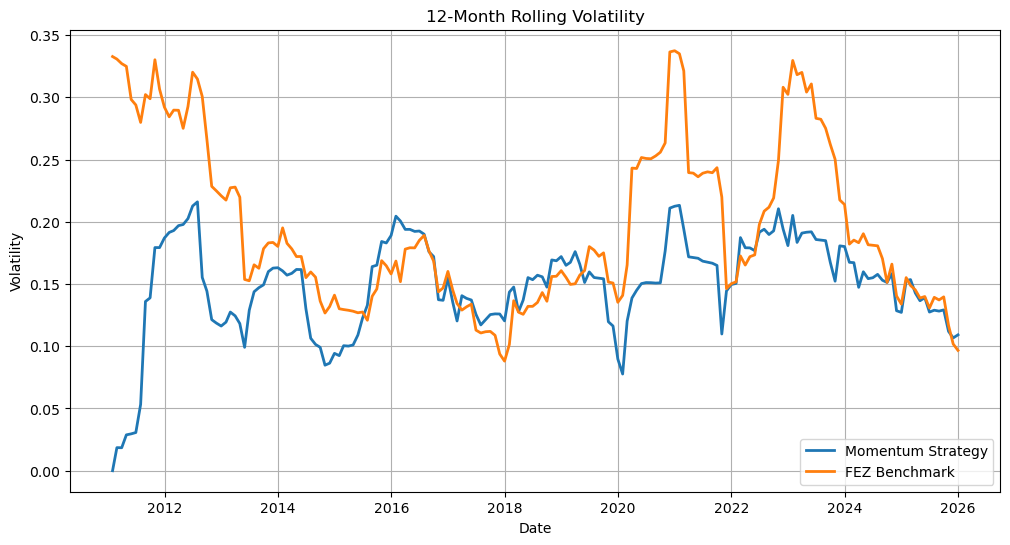

In [5]:
window = 12

strategy_rolling_vol = strategy_returns.rolling(window).std() * np.sqrt(12)
benchmark_rolling_vol = benchmark_returns.rolling(window).std() * np.sqrt(12)

plt.figure(figsize=(12, 6))
plt.plot(strategy_rolling_vol, label="Momentum Strategy", linewidth=2)
plt.plot(benchmark_rolling_vol, label="FEZ Benchmark", linewidth=2)
plt.title("12-Month Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.legend()
plt.grid(True)
plt.show()

## Interpretation

The drawdown analysis highlights the downside risk of the strategy compared to the benchmark.

The momentum strategy exhibits a maximum drawdown of -27.19%, while the FEZ benchmark reaches -37.23%.

This indicates that the strategy experiences smaller peak-to-trough losses than the market.

In other words, the momentum strategy not only generates returns but also provides better downside protection.

The rolling volatility analysis shows how risk evolves over time, with periods of higher volatility corresponding to market stress.

Overall, the strategy appears to deliver a more favorable risk profile compared to the benchmark.

# Turnover and Transaction Costs

## Objective
The objective of this section is to make the backtest more realistic by introducing transaction costs.

We compute :
- monthly portfolio turnover
- transaction costs based on turnover
- net strategy performance after costs

We then compare :
- gross momentum strategy
- net momentum strategy
- FEZ benchmark

This allows us to assess whether the strategy remains attractive after implementation costs.

## 1. Load Backtest Data
We reuse :
- the backtest summary table
- the invested portfolio weights

The invested weights correspond to the actual portfolio held each month after applying the one-month shift.


## 2. Extract Required Series
We extract :
- gross strategy returns
- FEZ benchmark equity curve
- invested portfolio weights

In [6]:
invested_weights = pd.read_csv("../data/invested_weights.csv", index_col=0, parse_dates=True)
backtest_summary.head()

gross_returns = backtest_summary["Strategy Return"]
gross_equity = backtest_summary["Strategy Equity"]
fez_equity = backtest_summary["FEZ Equity"]

## 3. Monthly Portfolio Turnover
Turnover measures how much the portfolio changes from one month to the next.

**Turnover_t = Σ |w_t - w_{t-1}|**
where:
- w_t represents the invested portfolio weights at month t
- w_{t-1} represents the invested portfolio weights at the previous month

Even though the portfolio uses equal weights, turnover still exists because the selected stocks change over time.

Why it matters :
- high turnover implies frequent trading
- frequent trading generates transaction costs
- transaction costs reduce net performance


## 4. Transaction Costs Assumption
We assume transaction costs of 10 basis points (10 bps) per traded amount.

**10 bps = 0.10% = 0.001**

**Transaction Cost_t = Turnover_t × 0.001**

This is a simplified but realistic assumption for liquid European large-cap equities.

The model does not explicitly include :
- bid-ask spread
- commissions
- market impact

In [7]:
# Monthly turnover based on changes in invested portfolio weights
turnover = invested_weights.diff().abs().sum(axis=1, min_count=1)
# Remove periods where the portfolio is not yet invested
turnover = turnover.dropna()
turnover.head(15)

print()

cost_rate = 0.001
transaction_costs = turnover * cost_rate
transaction_costs.head(15)

Date
2011-03-31    0.000000
2011-04-30    0.000286
2011-05-31    0.000286
2011-06-30    0.000571
2011-07-31    0.000571
2011-08-31    0.000571
2011-09-30    0.000571
2011-10-31    0.000286
2011-11-30    0.000571
2011-12-31    0.000286
2012-01-31    0.000000
2012-02-29    0.000571
2012-03-31    0.000571
2012-04-30    0.000000
2012-05-31    0.000286
dtype: float64

## 5. Net Strategy Returns

Gross returns represent the strategy performance before transaction costs.

Net returns are computed after subtracting transaction costs.

**Net Return_t = Gross Return_t - Transaction Cost_t**



## 6. Turnover Plot

This plot shows how much the portfolio changes each month.

Large spikes indicate periods with stronger portfolio rebalancing activity.



## 7. Gross vs Net Strategy Performance

We compare :
- gross momentum strategy
- net momentum strategy after costs
- FEZ benchmark

This allows us to evaluate whether the strategy remains attractive after realistic trading costs.

Date
2011-03-31    0.002503
2011-04-30    0.023814
2011-05-31   -0.004206
2011-06-30    0.012024
2011-07-31   -0.039576
2011-08-31   -0.124311
2011-09-30   -0.040592
2011-10-31    0.100357
2011-11-30   -0.001505
2011-12-31    0.048494
2012-01-31    0.041215
2012-02-29    0.030642
2012-03-31    0.043409
2012-04-30   -0.019358
2012-05-31   -0.039814
2012-06-30    0.065653
2012-07-31    0.071399
2012-08-31    0.008110
2012-09-30   -0.012075
2012-10-31    0.032136
2012-11-30    0.022329
2012-12-31    0.010453
2013-01-31    0.053847
2013-02-28   -0.024010
2013-03-31    0.020698
2013-04-30    0.019525
2013-05-31    0.024547
2013-06-30   -0.073773
2013-07-31    0.097390
2013-08-31   -0.016003
dtype: float64



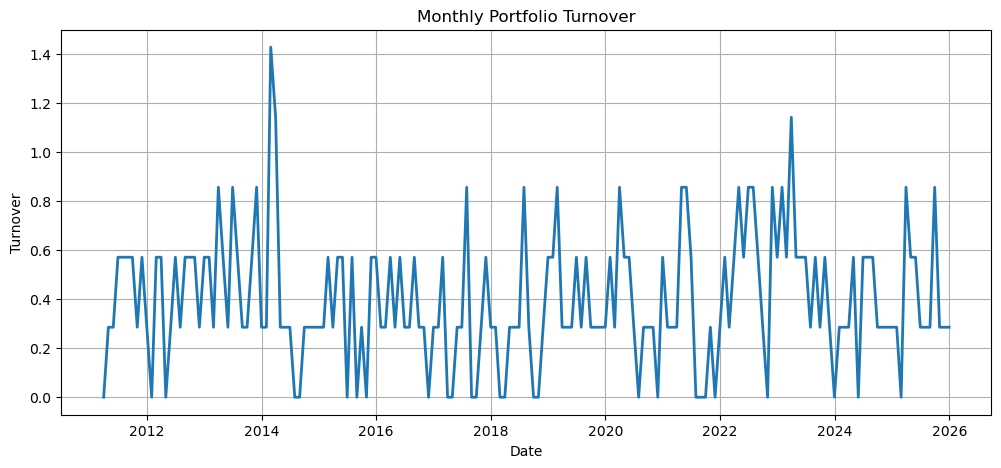

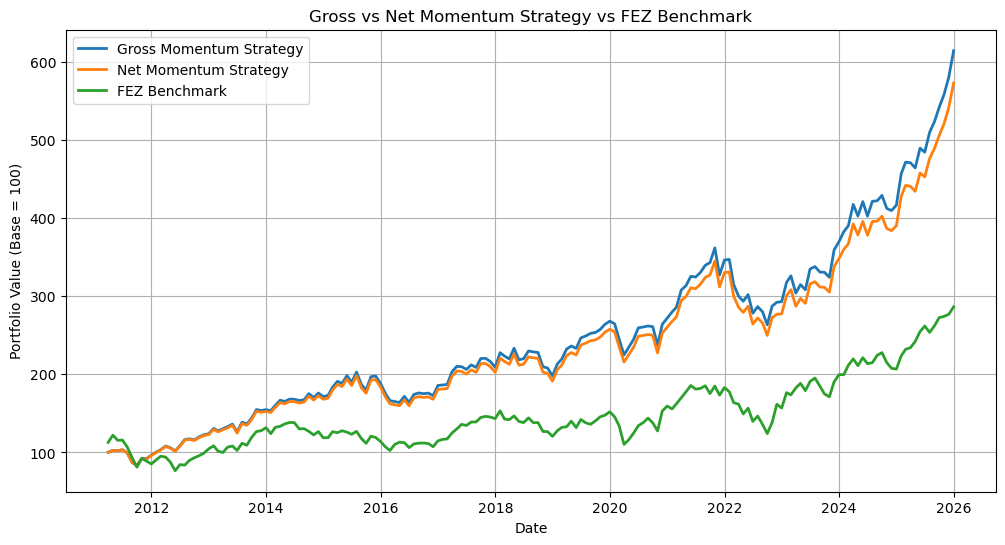

In [12]:
# Align gross returns and transaction costs
common_index = gross_returns.index.intersection(transaction_costs.index)
gross_returns = gross_returns.loc[common_index]
transaction_costs = transaction_costs.loc[common_index]

# Net returns after transaction costs
net_returns = gross_returns - transaction_costs

# Compute cumulative performance
gross_equity = 100 * (1 + gross_returns).cumprod()
net_equity = 100 * (1 + net_returns).cumprod()
print(net_returns.head(10))

print()

plt.figure(figsize=(12, 5))
plt.plot(turnover.loc[common_index], linewidth=2)
plt.title("Monthly Portfolio Turnover")
plt.xlabel("Date")
plt.ylabel("Turnover")
plt.grid(True)
plt.show()

print()

fez_equity = fez_equity.loc[net_equity.index]
plt.figure(figsize=(12, 6))
plt.plot(gross_equity, label="Gross Momentum Strategy", linewidth=2)
plt.plot(net_equity, label="Net Momentum Strategy", linewidth=2)
plt.plot(fez_equity, label="FEZ Benchmark", linewidth=2)
plt.title("Gross vs Net Momentum Strategy vs FEZ Benchmark")
plt.xlabel("Date")
plt.ylabel("Portfolio Value (Base = 100)")
plt.legend()
plt.grid(True)
plt.show()

## 8. Cost Impact Summary

We summarize :
- average monthly turnover
- average monthly transaction cost
- final gross portfolio value
- final net portfolio value

This helps quantify the impact of trading costs on the strategy.

In [9]:
cost_summary = pd.DataFrame({"Value": [turnover.loc[common_index].mean(),transaction_costs.mean(),gross_equity.iloc[-1],net_equity.iloc[-1],gross_equity.iloc[-1] - net_equity.iloc[-1]]}, 
                            index=["Average Monthly Turnover","Average Monthly Transaction Cost","Final Gross Equity","Final Net Equity","Final Equity Difference"])
cost_summary.round(4)

,Value
Average Monthly Turnover,0.3949
Average Monthly Transaction Cost,0.0004
Final Gross Equity,614.2491
Final Net Equity,572.8965
Final Equity Difference,41.3526


## 9. Interpretation

The turnover analysis shows how actively the portfolio changes over time.

Even though the strategy uses equal weights, transaction costs arise because stocks frequently enter and leave the momentum portfolio.

The comparison between gross and net equity curves allows us to evaluate whether the momentum strategy remains profitable after implementation costs.

If the net equity curve remains close to the gross curve, transaction costs have a limited impact.

If the gap becomes large, the strategy may be too sensitive to trading activity.

In [10]:
transaction_costs_summary = pd.DataFrame({"Gross Return": gross_returns,"Transaction Cost": transaction_costs,"Net Return": net_returns,
    "Gross Equity": gross_equity,"Net Equity": net_equity,"Turnover": turnover.loc[common_index]})

transaction_costs_summary.to_csv("../data/transaction_costs_summary.csv")

print("File saved successfully:")
print("- ../data/transaction_costs_summary.csv")

File saved successfully:
- ../data/transaction_costs_summary.csv
